Tutorial 3 (CH-4124)

####
Fitting chemical data
From raw numbers to a physical parameter: least squares, nonlinear fits, and log-linearisation.
####

### 1. NumPy warm-up and vectorised chemistry

Build arrays, apply the Beer-Lambert law elementwise, and add measurement noise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# Concentration grid (mol/L)
c =  np.linspace(0.0, 1.0e-3, 25)      # TO DO: np.linspace(0.0, 1.0e-3, 25)

epsilon = 8500.0    # TO DO: molar absorptivity, e.g., 8500.0 (L/mol/cm)
path_len = 1.0 # TO DO: cuvette path length in cm, e.g., 1.0

# Beer-Lambert: A = epsilon * l * c
A_true = epsilon * path_len * c     # TO DO: vectorised expression, no loop

# Add gaussian noise to mimic a real spectrometer
noise = rng.normal(loc=0.0, scale= 0.02, size=c.size)   # TO DO: scale e.g. 0.02
A_obs = A_true + noise   # TO DO: A_true + noise

print("shape:", A_obs.shape, "| max A:", A_obs.max().round(3))
print("mean:", A_obs.mean(), A_obs.std(), "| std:", ...)   # TO DO: A_obs.mean(), A_obs.std()

shape: (25,) | max A: 8.518
mean: 4.248531318429831 2.5551024249288647 | std: Ellipsis


### 2. Straight-line least squares

Fit A vs c, recover the molar absorptivity, and judge the fit quality with R-squared.

slope (eps*l): 8503.705194110798
recovered epsilon: 8503.705194110798
intercept: -0.0033212786255688077 | R2: 0.999955384520367


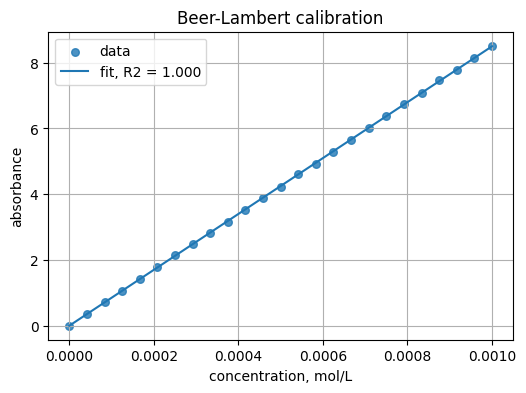

In [2]:
# Fit a first degree polynomial: A = m*c + b
coeffs = np.polyfit(c, A_obs, 1)        # TO DO: np.polyfit(c, A_obs, 1)
m, b =  coeffs    # TO DO: unpack coeffs

A_fit = np.polyval(coeffs, c) # TO DO: np.polyval(coeffs, c)

# R-squared
ss_res = np.sum((A_obs - A_fit)**2)        # TO DO: np.sum((A_obs - A_fit)**2)
ss_tot = np.sum((A_obs - A_obs.mean())**2)       # TO DO: np.sum((A_obs - A_obs.mean())**2)
r2 =   1 - ss_res/ss_tot           # TO DO: 1 - ss_res/ss_tot

print("slope (eps*l):", m)
print("recovered epsilon:", m / path_len)     # TO DO: m / path_len
print("intercept:", b, "| R2:", r2)

plt.figure(figsize=(6, 4))
plt.scatter(c, A_obs, s=30, alpha= 0.8, label="data")     # TO DO: e.g. 30, 0.8
plt.plot(c, A_fit, "-", label=f"fit, R2 = {r2:.3f}")
plt.xlabel("concentration, mol/L")
plt.ylabel("absorbance")
plt.title("Beer-Lambert calibration")
plt.legend()
plt.grid(True)

### 3. Residuals

A fit is only as good as its residuals. Plot them and look for structure.

mean residual: 9.44522238199852e-16
RMSE: 0.01706676062576445


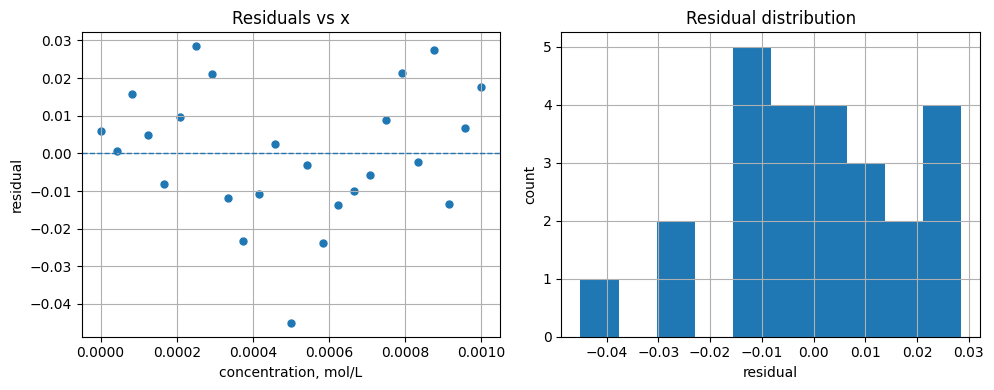

In [3]:
resid = A_obs - A_fit   # TO DO: A_obs - A_fit

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter( c, resid, s=25)        # TO DO: c, resid
axes[0].axhline(0.0, ls="--", lw=1)
axes[0].set_xlabel("concentration, mol/L")
axes[0].set_ylabel("residual")
axes[0].set_title("Residuals vs x")
axes[0].grid(True)

axes[1].hist( resid, bins= 10)            # TO DO: resid, e.g. 10
axes[1].set_xlabel("residual")
axes[1].set_ylabel("count")
axes[1].set_title("Residual distribution")
axes[1].grid(True)

plt.tight_layout()

print("mean residual:", resid.mean())           # TO DO: resid.mean()
print("RMSE:", np.sqrt(np.mean(resid**2)))                    # TO DO: np.sqrt(np.mean(resid**2))

### 4. Nonlinear fit — first order kinetics

A decays as [A] = [A]0 * exp(-k t). Fit it directly with `curve_fit`, then compare
against the linearised form ln[A] vs t.

A0 = 0.8357 +/- 0.0075
k  = 0.04342 +/- 0.00061 1/min
half life, min: 15.964784364506153


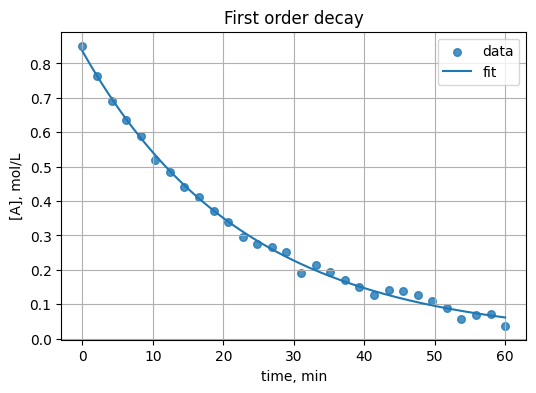

In [4]:
from scipy.optimize import curve_fit

# Synthetic kinetics run
t = np.linspace(0.0, 60.0, 30)          # minutes
A0_true, k_true = 0.85, 0.045
conc = A0_true*np.exp(-k_true*t) + rng.normal(0.0, 0.015, t.size)

def first_order(t, A0, k):
    return A0*np.exp(-k*t)                          # TO DO: A0*np.exp(-k*t)

p0 = [1.0, 0.01]                # TO DO: initial guess, e.g. [1.0, 0.01]
popt, pcov = curve_fit(first_order, t, conc, p0=p0) # TO DO: curve_fit(first_order, t, conc, p0=p0)

A0_fit, k_fit = popt                     # TO DO: unpack popt
perr =  np.sqrt(np.diag(pcov))                     # TO DO: np.sqrt(np.diag(pcov))

print(f"A0 = {A0_fit:.4f} +/- {perr[0]:.4f}")
print(f"k  = {k_fit:.5f} +/- {perr[1]:.5f} 1/min")
print("half life, min:", np.log(2)/k_fit)           # TO DO: np.log(2)/k_fit

t_smooth = np.linspace(t.min(), t.max(), 200)

plt.figure(figsize=(6, 4))
plt.scatter(t, conc, s=30, alpha=0.8, label="data")
plt.plot(t_smooth, first_order(t_smooth, *popt), "-", label="fit")   # TO DO: first_order(t_smooth, *popt)
plt.xlabel("time, min")
plt.ylabel("[A], mol/L")
plt.title("First order decay")
plt.legend()
plt.grid(True)

k from linearisation: 0.04469321398830805
k from curve_fit    : 0.043417259183342986


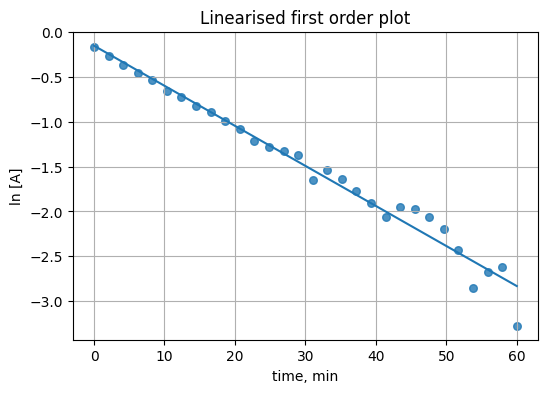

In [5]:
# Linearised check: ln[A] should be straight with slope -k
mask = conc > 0                    # guard against log of a negative noisy point
ln_c = np.log(conc[mask])                       # TO DO: np.log(conc[mask])

slope, intercept =  np.polyfit(t[mask], ln_c, 1)             # TO DO: np.polyfit(t[mask], ln_c, 1)
print("k from linearisation:", -slope)   # TO DO: -slope
print("k from curve_fit    :", k_fit)

plt.figure(figsize=(6, 4))
plt.scatter(t[mask], ln_c, s=30, alpha=0.8)
plt.plot(t[mask], np.polyval([slope, intercept], t[mask]), "-")        # TO DO: np.polyval([slope, intercept], t[mask])
plt.xlabel("time, min")
plt.ylabel("ln [A]")
plt.title("Linearised first order plot")
plt.grid(True)

### 5. New dataset — Arrhenius rate constants

Work with `arrhenius_rates.csv`, columns `run_id`, `temperature_K`, `rate_constant`, `catalyst`.
Tasks:

Read the CSV and inspect it
Add columns for 1/T and ln k
Fit ln k vs 1/T for each catalyst separately
Report Ea in kJ/mol and the pre-exponential factor A
Overlay both fits on one plot

In [7]:
import pandas as pd

path = "/content/arrhenius_rates.csv"

df = pd.read_csv(path)          # TO DO: pd.read_csv(path)
print(df.head())
print(df.info())
print(df["catalyst"].value_counts())

# Derived columns
df["inv_T"] = 1.0 / df["temperature_K"] # TO DO: 1.0 / df["temperature_K"]
df["ln_k"]  = np.log(df["rate_constant"])      # TO DO: np.log(df["rate_constant"])

df.head()

  run_id  temperature_K  rate_constant  catalyst
0   R003            325   5.026310e-04      Pd_C
1   R032            385   2.244798e-04  Ni_Al2O3
2   R004            325   5.064776e-04      Pd_C
3   R022            310   2.763139e-08  Ni_Al2O3
4   R028            355   2.030964e-05  Ni_Al2O3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   run_id         40 non-null     object 
 1   temperature_K  40 non-null     int64  
 2   rate_constant  36 non-null     float64
 3   catalyst       40 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.4+ KB
None
catalyst
Pd_C        20
Ni_Al2O3    20
Name: count, dtype: int64


,run_id,temperature_K,rate_constant,catalyst,inv_T,ln_k
0,R003,325,5.026310e-04,Pd_C,0.003077,-7.595654
1,R032,385,2.244798e-04,Ni_Al2O3,0.002597,-8.401725
2,R004,325,5.064776e-04,Pd_C,0.003077,-7.588030
3,R022,310,2.763139e-08,Ni_Al2O3,0.003226,-17.404313
4,R028,355,2.030964e-05,Ni_Al2O3,0.002817,-10.804415


In [8]:
R = 8.314   # J/mol/K

results = {}

for cat, grp in df.groupby("catalyst"):                       # TO DO: df.groupby("catalyst")
    x = grp["inv_T"].to_numpy()
    y = grp["ln_k"].to_numpy()                           # TO DO: grp["ln_k"].to_numpy()

    slope, intercept = np.polyfit(x, y, 1)                 # TO DO: np.polyfit(x, y, 1)

    Ea_kJ = -slope * R / 1000.0               # TO DO: -slope * R / 1000.0
    A_pre = np.exp(intercept)                 # TO DO: np.exp(intercept)

    results[cat] = {"slope": slope, "intercept": intercept,
                    "Ea_kJ_per_mol": Ea_kJ, "A": A_pre, "n": len(grp)}

    print(f"{cat:>12} | Ea = {Ea_kJ:7.2f} kJ/mol | A = {A_pre:.3e} | n = {len(grp)}")

summary = pd.DataFrame(results).T
summary

    Ni_Al2O3 | Ea =     nan kJ/mol | A = nan | n = 20
        Pd_C | Ea =     nan kJ/mol | A = nan | n = 20


,slope,intercept,Ea_kJ_per_mol,A,n
Ni_Al2O3,NaN,NaN,NaN,NaN,20.0
Pd_C,NaN,NaN,NaN,NaN,20.0


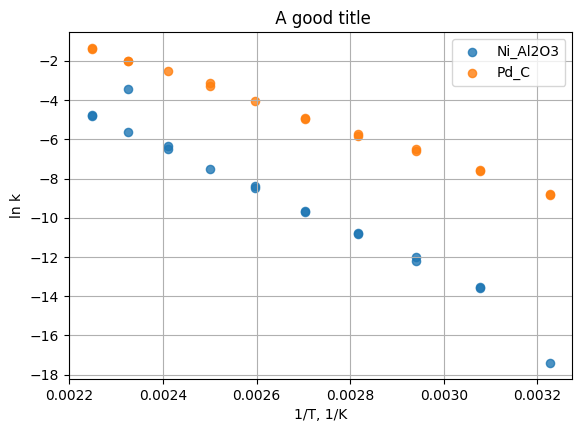

In [9]:
plt.figure(figsize=(6.5, 4.5))

for cat, grp in df.groupby("catalyst"):
    x = grp["inv_T"].to_numpy()
    y = grp["ln_k"].to_numpy()
    plt.scatter(x, y, s= 35, alpha= 0.8, label=cat)          # TO DO: e.g. 35, 0.8

    fit = results[cat]
    xs = np.linspace(x.min(), x.max(), 50)
    plt.plot(xs, fit["slope"]*xs + fit["intercept"], "--")                                  # TO DO: fit["slope"]*xs + fit["intercept"]

plt.xlabel("1/T, 1/K")
plt.ylabel("ln k")
plt.title( " A good title")                                               # TO DO: give it a title
plt.legend()
plt.grid(...)                                                # TO DO

### 6. Messy data

Real files have blanks and outliers. Clean before fitting.

In [10]:
# How many missing values per column?
print(df.isna().sum())                        # TO DO: df.isna().sum()

# Drop rows missing the rate constant
df_clean = df.dropna(subset=["rate_constant"]).copy()           # TO DO: df.dropna(subset=["rate_constant"]).copy()
print("rows before:", len(df), "| after:", len(df_clean))

# Flag outliers with a z-score on ln k, per catalyst
z = df_clean.groupby("catalyst")["ln_k"].transform(lambda s: (s - s.mean()) / s.std())
df_clean["is_outlier"] = z.abs() > 2.5     # TO DO: z.abs() > 2.5
print(df_clean["is_outlier"].sum(), "outliers flagged")

df_ok = df_clean[~df_clean["is_outlier"]]               # TO DO: df_clean[~df_clean["is_outlier"]]

# Refit one catalyst with and without outliers and compare Ea
cat = "Ni_Al2O3"  # TO DO: pick a catalyst name from the file
sub_all = df_clean[df_clean["catalyst"] == cat]
sub_ok  = df_ok[df_ok["catalyst"] == cat]

for name, sub in [("with outliers", sub_all), ("cleaned", sub_ok)]:
    s, _ = np.polyfit(sub["inv_T"], sub["ln_k"], 1)
    print(f"{name:>14}: Ea = {-s*R/1000:.2f} kJ/mol")

run_id           0
temperature_K    0
rate_constant    4
catalyst         0
inv_T            0
ln_k             4
dtype: int64
rows before: 40 | after: 36
0 outliers flagged
 with outliers: Ea = 98.56 kJ/mol
       cleaned: Ea = 98.56 kJ/mol


### 7. Publication-style figure

Two panels side by side, shared styling, saved to disk at 300 dpi.

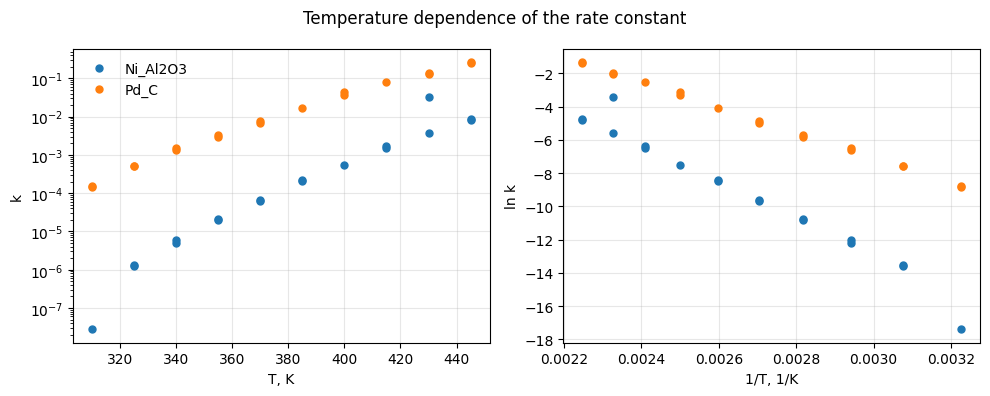

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))   # TO DO: e.g. 10, 4

# Left: k vs T
for cat, grp in df.groupby("catalyst"):
    ax1.plot(grp["temperature_K"], grp["rate_constant"], "o", ms=5, label=cat)
ax1.set_yscale('log')                # TO DO: "log"
ax1.set_xlabel("T, K")
ax1.set_ylabel("k")
ax1.legend(frameon=False)
ax1.grid(True, alpha=0.3)

# Right: Arrhenius
for cat, grp in df.groupby("catalyst"):
    ax2.plot( grp["inv_T"], grp["ln_k"], "o", ms=5, label=cat)
ax2.set_xlabel("1/T, 1/K")
ax2.set_ylabel("ln k")
ax2.grid(True, alpha=0.3)

fig.suptitle("Temperature dependence of the rate constant")
fig.tight_layout()
fig.savefig("arrhenius_figure.png", dpi= 300)          # TO DO: "arrhenius_figure.png", 300

### 8. Practice on your own

Repeat the whole pipeline on `enzyme_kinetics.csv` with columns
`substrate_mM`, `velocity_uM_per_min`, `enzyme_batch`.

1. Fit the Michaelis-Menten form v = Vmax*S / (Km + S) with `curve_fit`
2. Report Vmax and Km with their uncertainties for each batch
3. Make a Lineweaver-Burk plot (1/v vs 1/S) and fit it linearly
4. Compare Km from the nonlinear fit against Km from the linearised fit,
   and write one or two sentences on why they disagree

In [16]:
from scipy.optimize import curve_fit

def michaelis_menten(S, Vmax, Km):
       return Vmax * S / (Km + S)
df2=pd.read_csv("/content/enzyme_kinetics.csv")

batch_results = {}

for batch_name, grp in df2.groupby('enzyme_batch'):
    S_data = grp['substrate_mM'].to_numpy()
    v_data = grp['velocity_uM_per_min'].to_numpy()

    # Nonlinear fit (Michaelis-Menten)
    p0 = [v_data.max(), S_data.mean()] # Initial guess for Vmax, Km
    try:
        popt, pcov = curve_fit(michaelis_menten, S_data, v_data, p0=p0)
        Vmax_nl, Km_nl = popt
        perr_nl = np.sqrt(np.diag(pcov))
        Vmax_nl_err, Km_nl_err = perr_nl
    except RuntimeError:
        print(f"Could not fit nonlinear Michaelis-Menten for batch {batch_name}")
        Vmax_nl, Km_nl, Vmax_nl_err, Km_nl_err = np.nan, np.nan, np.nan, np.nan

    # Lineweaver-Burk (linear fit)
    # Filter out zero velocities to avoid division by zero
    mask_lb = v_data > 0
    S_lb = S_data[mask_lb]
    v_lb = v_data[mask_lb]

    inv_S = 1 / S_lb
    inv_v = 1 / v_lb

    try:
        coeffs_lb = np.polyfit(inv_S, inv_v, 1)
        slope_lb, intercept_lb = coeffs_lb

        # From Lineweaver-Burk: 1/v = (Km/Vmax) * (1/S) + 1/Vmax
        Vmax_lin = 1 / intercept_lb
        Km_lin = slope_lb * Vmax_lin
    except Exception:
        print(f"Could not fit Lineweaver-Burk for batch {batch_name}")
        Vmax_lin, Km_lin = np.nan, np.nan

    batch_results[batch_name] = {
        'Vmax_nl': Vmax_nl, 'Km_nl': Km_nl,
        'Vmax_nl_err': Vmax_nl_err, 'Km_nl_err': Km_nl_err,
        'Vmax_lin': Vmax_lin, 'Km_lin': Km_lin
    }

    print(f"\n--- Results for Batch: {batch_name} ---")
    print(f"Nonlinear Fit:")
    print(f"  Vmax = {Vmax_nl:.4f} +/- {Vmax_nl_err:.4f} uM/min")
    print(f"  Km   = {Km_nl:.4f} +/- {Km_nl_err:.4f} mM")
    print(f"Lineweaver-Burk Fit:")
    print(f"  Vmax = {Vmax_lin:.4f} uM/min")
    print(f"  Km   = {Km_lin:.4f} mM")

# TO DO: add plotting in subsequent cells
# TO DO: add markdown explanation for Km disagreement


--- Results for Batch: batch_A ---
Nonlinear Fit:
  Vmax = 122.0173 +/- 1.6338 uM/min
  Km   = 0.4542 +/- 0.0271 mM
Lineweaver-Burk Fit:
  Vmax = 122.8959 uM/min
  Km   = 0.4631 mM

--- Results for Batch: batch_B ---
Nonlinear Fit:
  Vmax = 94.6138 +/- 2.0063 uM/min
  Km   = 1.1365 +/- 0.0831 mM
Lineweaver-Burk Fit:
  Vmax = 57.8327 uM/min
  Km   = 0.4429 mM

--- Results for Batch: batch_C ---
Nonlinear Fit:
  Vmax = 137.6220 +/- 2.2123 uM/min
  Km   = 0.6060 +/- 0.0401 mM
Lineweaver-Burk Fit:
  Vmax = 193.7699 uM/min
  Km   = 1.1065 mM


#### Visualization of Fits and Comparison of Km Values

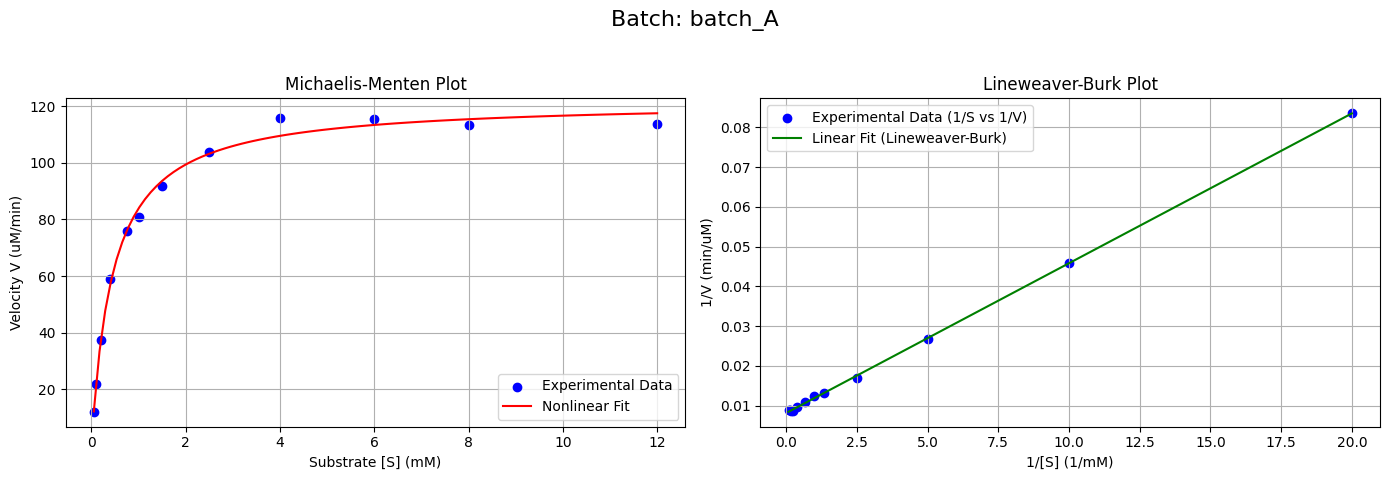

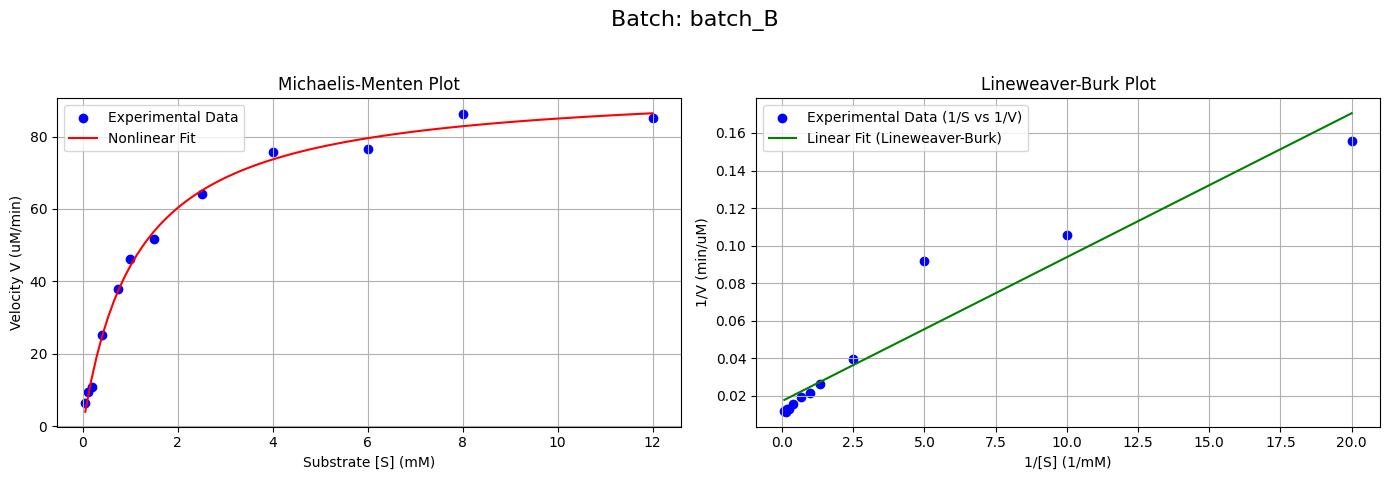

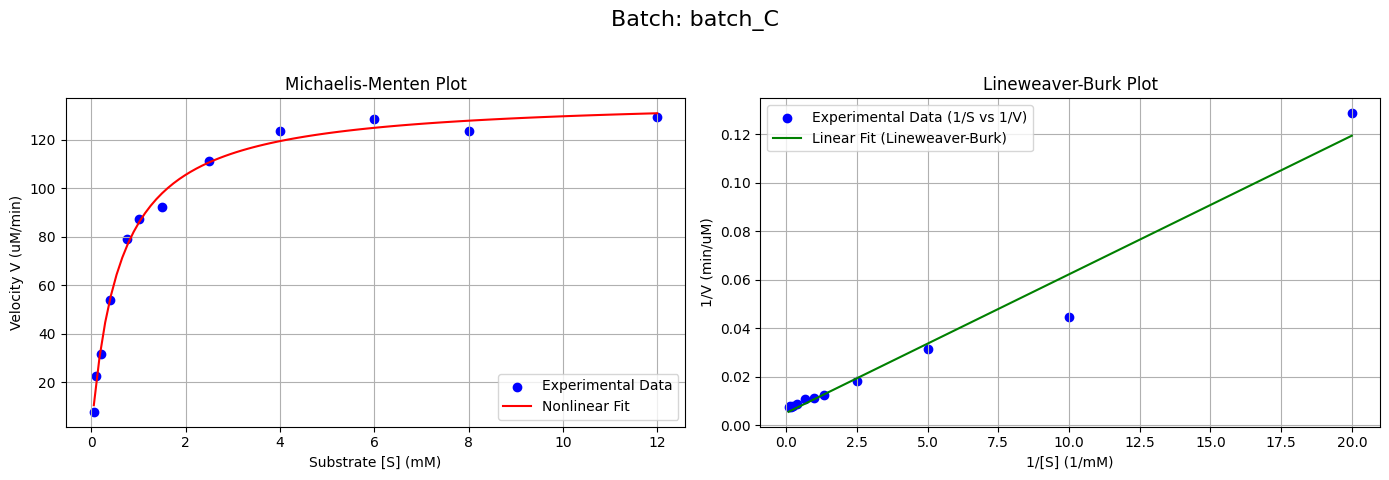

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def michaelis_menten(S, Vmax, Km):
    return Vmax * S / (Km + S)

for batch_name, grp in df2.groupby('enzyme_batch'):
    S_data = grp['substrate_mM'].to_numpy()
    v_data = grp['velocity_uM_per_min'].to_numpy()
    results = batch_results[batch_name]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Batch: {batch_name}', fontsize=16)

    # Plot 1: Michaelis-Menten Plot (Nonlinear Fit)
    axes[0].scatter(S_data, v_data, label='Experimental Data', color='blue')
    S_smooth = np.linspace(S_data.min(), S_data.max(), 100)
    v_nl_fit = michaelis_menten(S_smooth, results['Vmax_nl'], results['Km_nl'])
    axes[0].plot(S_smooth, v_nl_fit, color='red', label='Nonlinear Fit')
    axes[0].set_xlabel('Substrate [S] (mM)')
    axes[0].set_ylabel('Velocity V (uM/min)')
    axes[0].set_title('Michaelis-Menten Plot')
    axes[0].legend()
    axes[0].grid(True)

    # Plot 2: Lineweaver-Burk Plot (Linear Fit)
    mask_lb = v_data > 0
    inv_S = 1 / S_data[mask_lb]
    inv_v = 1 / v_data[mask_lb]

    axes[1].scatter(inv_S, inv_v, label='Experimental Data (1/S vs 1/V)', color='blue')
    inv_S_smooth = np.linspace(inv_S.min(), inv_S.max(), 100)
    # 1/v = (Km/Vmax) * (1/S) + 1/Vmax
    # slope = Km/Vmax, intercept = 1/Vmax
    slope_lb = results['Km_lin'] / results['Vmax_lin']
    intercept_lb = 1 / results['Vmax_lin']

    inv_v_lin_fit = slope_lb * inv_S_smooth + intercept_lb
    axes[1].plot(inv_S_smooth, inv_v_lin_fit, color='green', label='Linear Fit (Lineweaver-Burk)')
    axes[1].set_xlabel('1/[S] (1/mM)')
    axes[1].set_ylabel('1/V (min/uM)')
    axes[1].set_title('Lineweaver-Burk Plot')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()


#### Comparison of Km from Nonlinear and Linearized Fits



The Km values disagree between nonlinear and linearized fits because data transformations for linearization can change the error distribution, giving disproportionate weight to certain data points and making the fit more sensitive to experimental errors, especially at low substrate concentrations.